In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [28]:
df = pd.read_csv("Global_Cybersecurity_Threats_2015-2024.csv")
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [40]:
df.columns

Index(['Country', 'Year', 'Attack Type', 'Target Industry',
       'Financial Loss (in Million $)', 'Number of Affected Users',
       'Attack Source', 'Security Vulnerability Type',
       'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'],
      dtype='object')

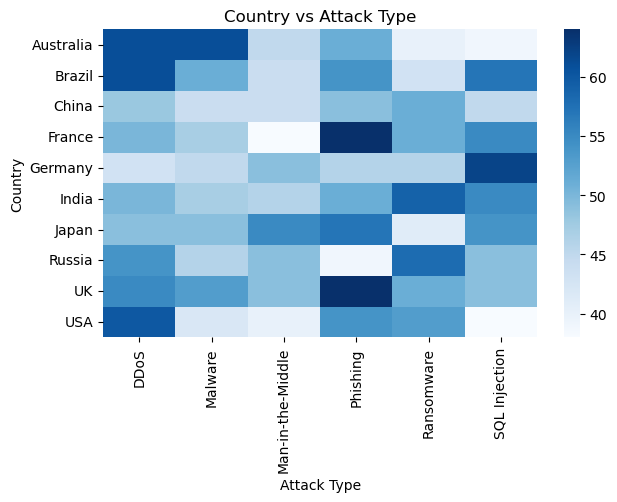

In [45]:
plt.figure(figsize=(7,4))
country_attack = pd.crosstab(df['Country'], df['Attack Type'])
sns.heatmap(country_attack, cmap="Blues")
plt.title("Country vs Attack Type")
plt.show()

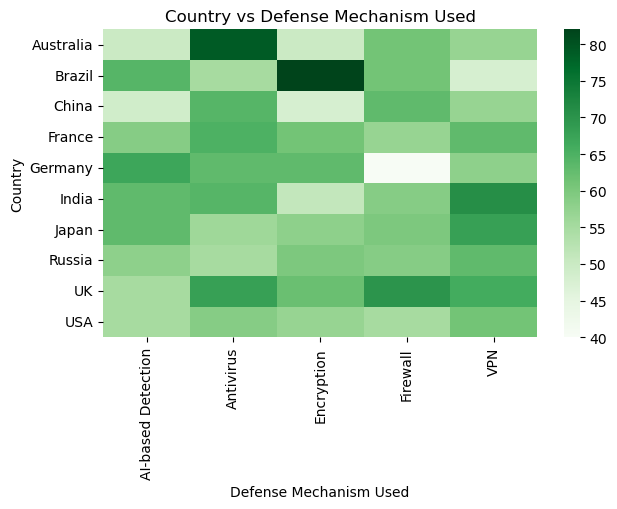

In [47]:
plt.figure(figsize=(7,4))
country_defense = pd.crosstab(df['Country'], df['Defense Mechanism Used'])
sns.heatmap(country_defense, cmap="Greens")
plt.title("Country vs Defense Mechanism Used")
plt.show()

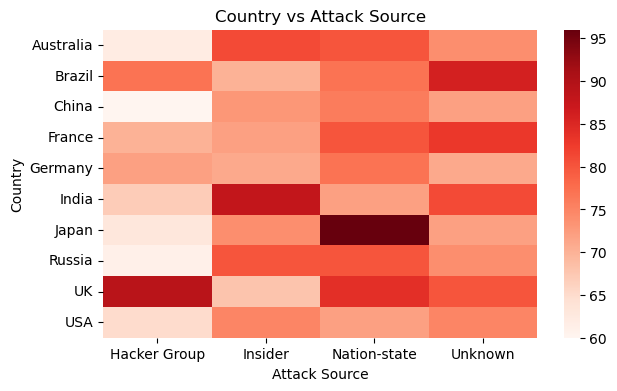

In [49]:
plt.figure(figsize=(7,4))
country_source = pd.crosstab(df['Country'], df['Attack Source'])
sns.heatmap(country_source, cmap="Reds")
plt.title("Country vs Attack Source")
plt.show()

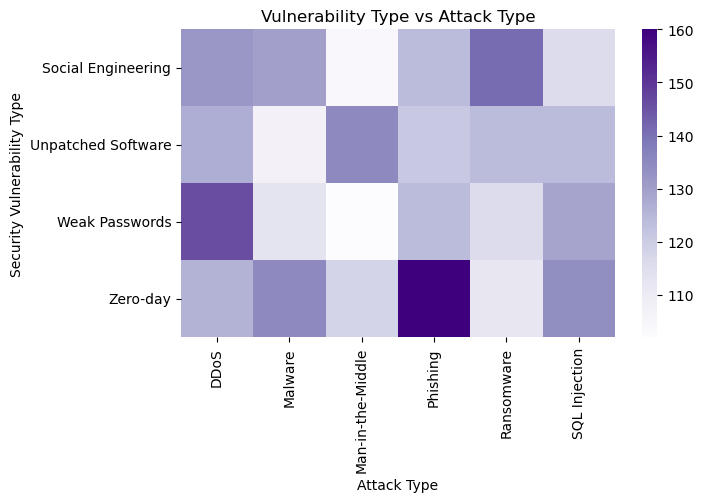

In [51]:
plt.figure(figsize=(7,4))
vul_attack = pd.crosstab(df['Security Vulnerability Type'], df['Attack Type'])
sns.heatmap(vul_attack, cmap="Purples")
plt.title("Vulnerability Type vs Attack Type")
plt.show()

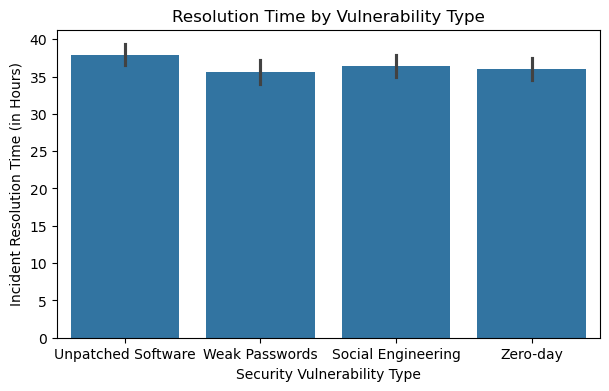

In [66]:
plt.figure(figsize=(7,4))
sns.barplot(data=df,
            x='Security Vulnerability Type',
            y='Incident Resolution Time (in Hours)')
plt.title("Resolution Time by Vulnerability Type")
plt.show()

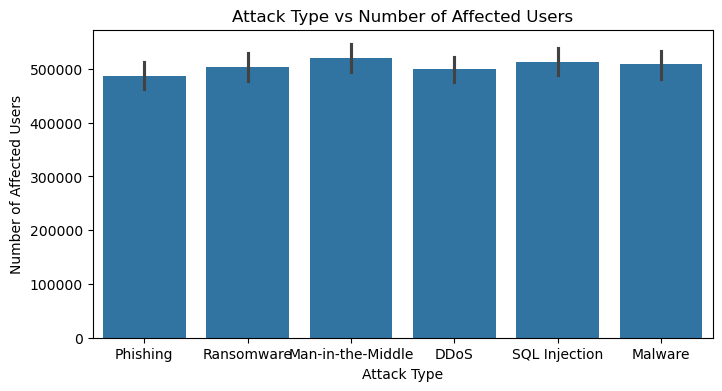

In [64]:
plt.figure(figsize=(8,4))
sns.barplot(data=df,
            x='Attack Type',
            y='Number of Affected Users')
plt.title("Attack Type vs Number of Affected Users")
plt.show()

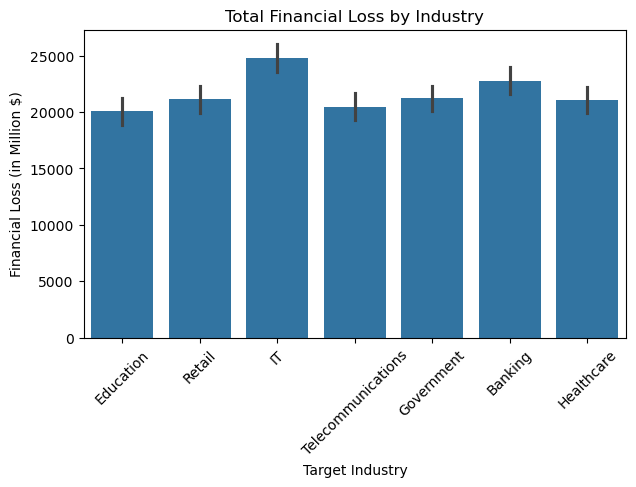

In [63]:
plt.figure(figsize=(7,4))
sns.barplot(data=df,
            x='Target Industry',
            y='Financial Loss (in Million $)',
            estimator=sum)
plt.xticks(rotation=45)
plt.title("Total Financial Loss by Industry")
plt.show()

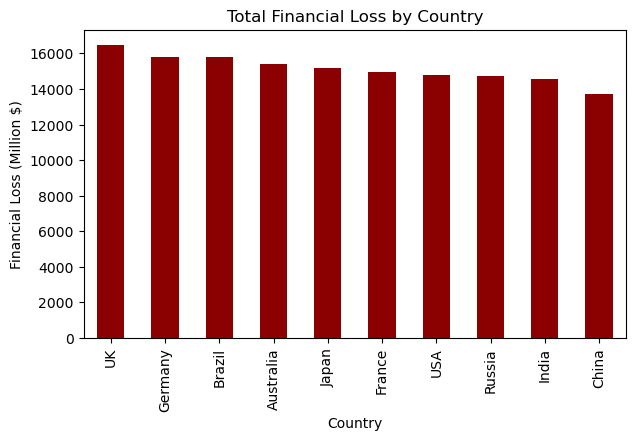

Country with highest financial loss:
Country
UK    16502.99
Name: Financial Loss (in Million $), dtype: float64


In [73]:
country_loss = df.groupby('Country')['Financial Loss (in Million $)'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,4))
country_loss.plot(kind='bar',color="darkred")
plt.title("Total Financial Loss by Country")
plt.ylabel("Financial Loss (Million $)")
plt.show()

print("Country with highest financial loss:")
print(country_loss.head(1))

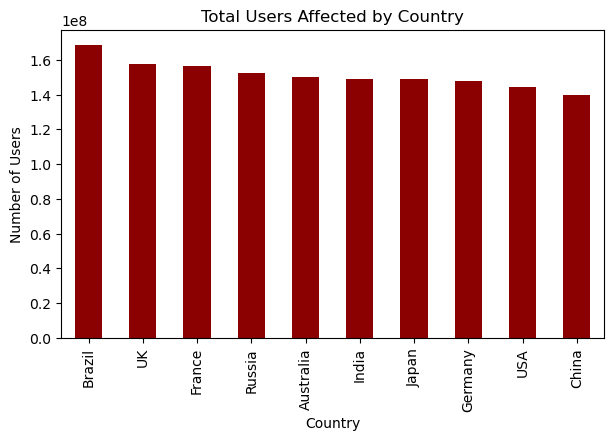

Country with most affected users:
Country
Brazil    168806980
Name: Number of Affected Users, dtype: int64


In [72]:
country_users = df.groupby('Country')['Number of Affected Users'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,4))
country_users.plot(kind='bar',color="darkred")
plt.title("Total Users Affected by Country")
plt.ylabel("Number of Users")
plt.show()

print("Country with most affected users:")
print(country_users.head(1))

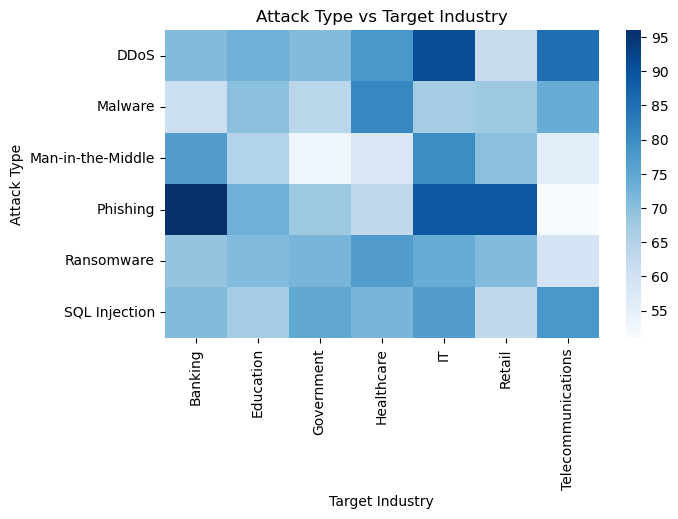

In [43]:
pivot = pd.crosstab(df["Attack Type"], df["Target Industry"])

plt.figure(figsize=(7,4))
sns.heatmap(pivot, cmap="Blues")
plt.title("Attack Type vs Target Industry")
plt.show()

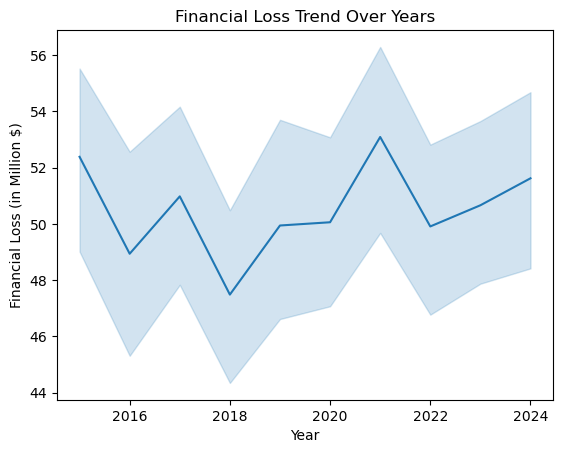

In [30]:
sns.lineplot(data=df, x="Year", y="Financial Loss (in Million $)")
plt.title("Financial Loss Trend Over Years")
plt.show()

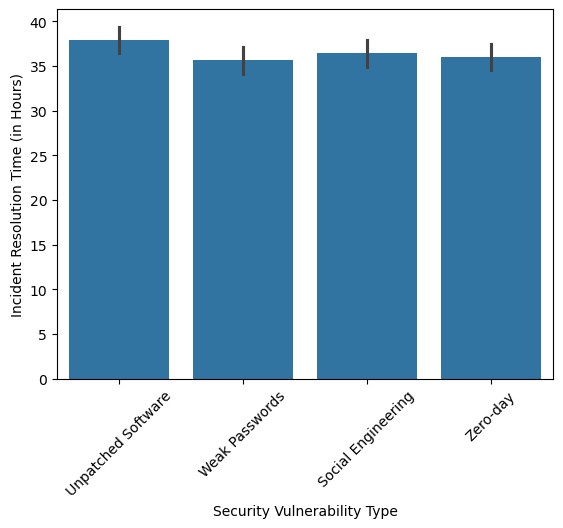

<Figure size 700x400 with 0 Axes>

In [80]:
sns.barplot(data=df,
            x='Security Vulnerability Type',
            y='Incident Resolution Time (in Hours)')
plt.xticks(rotation=45)
plt.figure(figsize=(7,4))
plt.show()

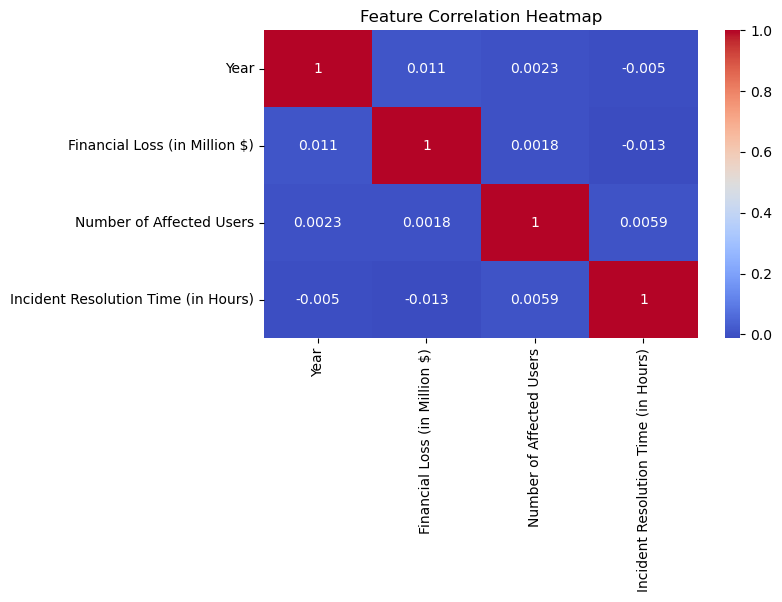

In [42]:
plt.figure(figsize=(7,4))
sns.heatmap(df.corr(numeric_only=True), 
            annot=True, 
            cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

no strong correlation!
Let's see it for non-linear relationship.

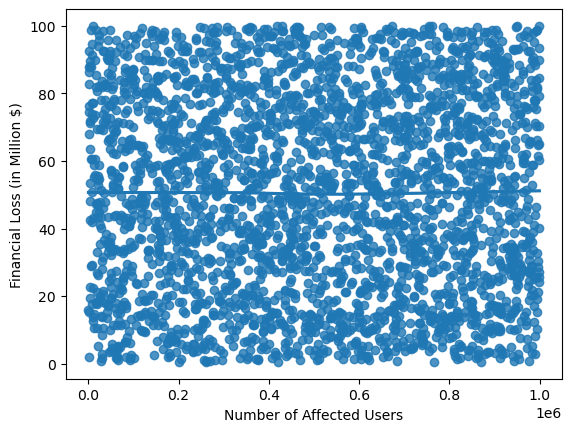

In [75]:
sns.regplot(data=df,
            x='Number of Affected Users',
            y='Financial Loss (in Million $)',
            lowess=True)
plt.show()

In [76]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['Number of Affected Users']]
y = df['Financial Loss (in Million $)']

lin = LinearRegression().fit(X, y)
r2_linear = r2_score(y, lin.predict(X))

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_model = LinearRegression().fit(X_poly, y)
r2_poly = r2_score(y, poly_model.predict(X_poly))

print("Linear R²:", r2_linear)
print("Polynomial R²:", r2_poly)

Linear R²: 3.192424004483385e-06
Polynomial R²: 6.395232515599147e-05


There is no significant linear or non-linear relationship between:

Number of Affected Users and Financial Loss (in Million $)
The variables behave independently in this dataset.Thus,
Financial Loss depends more on categorical patterns, Not on numeric magnitude directly.
Although financial loss could not be reliably predicted due to weak statistical relationships, but still we can extract other information.

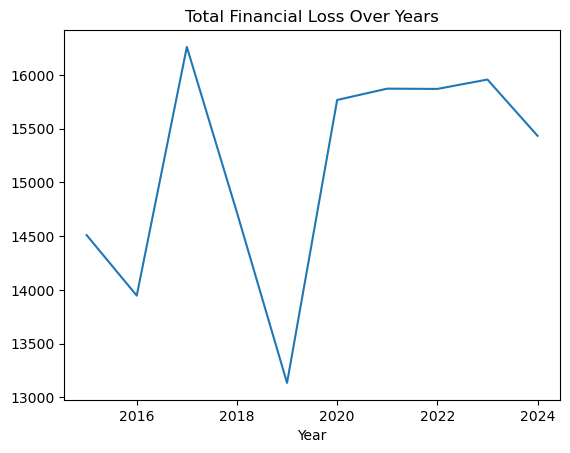

In [87]:
df.groupby('Year')['Financial Loss (in Million $)'].sum().plot()
plt.title("Total Financial Loss Over Years")
plt.show()

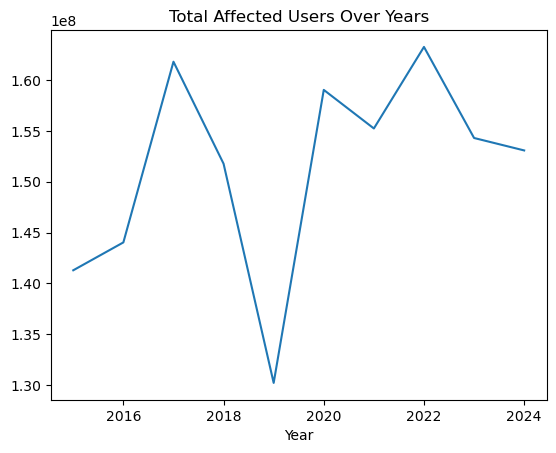

In [88]:
df.groupby('Year')['Number of Affected Users'].sum().plot()
plt.title("Total Affected Users Over Years")
plt.show()

In [89]:
country_stats = df.groupby('Country').agg({
    'Financial Loss (in Million $)': 'sum',
    'Number of Affected Users': 'sum',
    'Incident Resolution Time (in Hours)': 'mean'
}).sort_values(by='Financial Loss (in Million $)', ascending=False)

country_stats.head(10)

,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
Country,,,
UK,16502.99,157464983,36.925234
Germany,15793.24,147675358,36.017182
Brazil,15782.62,168806980,37.761290
Australia,15403.00,150011830,36.481481
Japan,15197.34,148711814,37.098361
France,14972.28,156229142,36.216393
USA,14812.12,144200870,35.306620
Russia,14734.73,152191835,35.535593
India,14566.12,149178659,35.931818


In [91]:
df.groupby('Defense Mechanism Used')['Incident Resolution Time (in Hours)'].mean().sort_values()

Defense Mechanism Used
Firewall              35.714530
Antivirus             36.573248
Encryption            36.589527
AI-based Detection    36.612350
VPN                   36.864379
Name: Incident Resolution Time (in Hours), dtype: float64

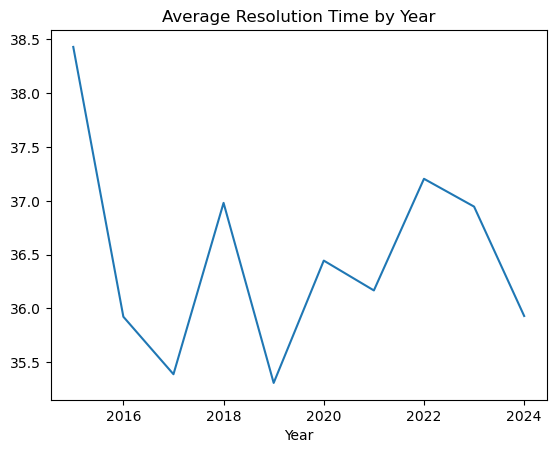

In [93]:
df.groupby('Year')['Incident Resolution Time (in Hours)'].mean().plot()
plt.title("Average Resolution Time by Year")
plt.show()

2015 is highest (~38.4 hrs)
Slowest resolution time in the period.

Drop from 2015 → 2017 (~35.4 hrs)
Indicates improvement in response capability.

Fluctuations from 2018–2023
No steady downward trend.

Resolution time increases again around 2022 (~37.2 hrs)

2024 slightly lower (~35.9 hrs)
Suggests moderate recovery in efficiency.

In [97]:
defense_summary = df.groupby('Defense Mechanism Used').agg({
    'Incident Resolution Time (in Hours)': 'mean',
    'Financial Loss (in Million $)': 'mean',
    'Number of Affected Users': 'mean'
}).sort_values(by='Financial Loss (in Million $)')

defense_summary

,Incident Resolution Time (in Hours),Financial Loss (in Million $),Number of Affected Users
Defense Mechanism Used,,,
Firewall,35.714530,49.719709,518014.468376
VPN,36.864379,50.209673,499117.874183
AI-based Detection,36.612350,50.361527,505632.732419
Encryption,36.589527,50.400203,490803.555743
Antivirus,36.573248,51.698838,509895.251592


Comparative evaluation of defense mechanisms indicates marginal performance differences. Firewalls demonstrate relatively superior effectiveness in reducing financial loss and resolution time, while encryption shows strength in limiting affected users. However, performance gaps across mechanisms remain small, suggesting balanced defensive effectiveness across strategies.